# Predicción de Enfermedad Cardíaca mediante Machine Learning

## Metodología CRISP-DM

**Dataset:** Heart Disease Dataset  
**Algoritmo:** Random Forest  
**Tipo de problema:** Clasificación binaria

**Integrantes:**  
- Gabriel Troyano
- Cristian Ruano
- Camila Collazos
- Santiago Lopez
- Andres Chicaiza
- Alejandro Anaya

**Asignatura:** Inteligencia Artificial
**Fecha:**  Septiembre de 2026

# 1. Comprensión del negocio

## 1.1 Contexto

Una startup del sector Health-Tech desea integrar una herramienta de apoyo
a la decisión clínica dentro de un sistema de historia clínica electrónica.

La herramienta busca analizar variables clínicas, signos vitales y resultados
de laboratorio de un paciente para identificar si existen indicios asociados
con la presencia de enfermedad cardíaca.

El sistema generaría una alerta para el profesional de la salud cuando el
modelo estime que el paciente presenta una mayor probabilidad de pertenecer
a la categoría de enfermedad cardíaca.

## 1.2 Problema de negocio

El problema consiste en desarrollar un modelo de Machine Learning capaz de
clasificar pacientes en dos categorías:

- 0: ausencia de enfermedad cardíaca.
- 1: presencia de enfermedad cardíaca.

El modelo estaría orientado a funcionar como una herramienta de apoyo para
el profesional de la salud y no como un mecanismo de diagnóstico médico.

## 1.3 Objetivo general

Desarrollar y evaluar un modelo de Machine Learning capaz de clasificar la
presencia o ausencia de enfermedad cardíaca a partir de variables clínicas,
aplicando técnicas de limpieza, preparación, análisis exploratorio,
normalización, entrenamiento y evaluación mediante la metodología CRISP-DM.

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

## 2.1 Carga del conjunto de datos

El conjunto de datos utilizado corresponde al Heart Disease Dataset,
obtenido de Kaggle.

El archivo utilizado para el análisis se denomina `heart.csv`.

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2.2 Dimensiones del conjunto de datos

In [3]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("Dimensiones:", df.shape)


Número de filas: 1025
Número de columnas: 14
Dimensiones: (1025, 14)


## 2.3 Información general de las variables

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## 2.4 Estadísticas descriptivas

Se calculan estadísticas descriptivas para conocer la distribución general
de las variables numéricas, incluyendo medidas como media, desviación
estándar, valores mínimos y máximos.

In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 2.5 Valores únicos de las variables

Se revisan los valores únicos de cada variable con el objetivo de detectar
posibles valores inesperados, códigos incorrectos o inconsistencias.

In [6]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())


age:
[52 53 70 61 62 58 55 46 54 71 43 34 51 50 60 67 45 63 42 44 56 57 59 64
 65 41 66 38 49 48 29 37 47 68 76 40 39 77 69 35 74]

sex:
[1 0]

cp:
[0 1 2 3]

trestbps:
[125 140 145 148 138 100 114 160 120 122 112 132 118 128 124 106 104 135
 130 136 180 129 150 178 146 117 152 154 170 134 174 144 108 123 110 142
 126 192 115  94 200 165 102 105 155 172 164 156 101]

chol:
[212 203 174 294 248 318 289 249 286 149 341 210 298 204 308 266 244 211
 185 223 208 252 209 307 233 319 256 327 169 131 269 196 231 213 271 263
 229 360 258 330 342 226 228 278 230 283 241 175 188 217 193 245 232 299
 288 197 315 215 164 326 207 177 257 255 187 201 220 268 267 236 303 282
 126 309 186 275 281 206 335 218 254 295 417 260 240 302 192 225 325 235
 274 234 182 167 172 321 300 199 564 157 304 222 184 354 160 247 239 246
 409 293 180 250 221 200 227 243 311 261 242 205 306 219 353 198 394 183
 237 224 265 313 340 259 270 216 264 276 322 214 273 253 176 284 305 168
 407 290 277 262 195 166 178 141]

fbs:

# 3. Preparación de los datos

## 3.1 Identificación de valores faltantes

Se verifica la existencia de valores nulos o faltantes en las variables del
conjunto de datos.

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
print("Total de valores faltantes:", df.isnull().sum().sum())

Total de valores faltantes: 0


 ## 3.2 Identificación de registros duplicados

Se analizan los registros duplicados para evitar que las mismas observaciones
tengan una influencia excesiva durante el entrenamiento del modelo.DUPLICADOS

In [9]:
duplicados = df.duplicated().sum()

print("Número de registros duplicados:", duplicados)

Número de registros duplicados: 723


In [10]:
porcentaje_duplicados = (duplicados / len(df)) * 100

print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")

Porcentaje de duplicados: 70.54%


## ELIMINAR DUPLICADOS

In [11]:
df_clean = df.drop_duplicates().copy()

print("Filas originales:", len(df))
print("Filas después de eliminar duplicados:", len(df_clean))

Filas originales: 1025
Filas después de eliminar duplicados: 302


In [12]:
print("Duplicados restantes:", df_clean.duplicated().sum())

Duplicados restantes: 0


## 3.3 Identificación de valores inválidos

Se revisan los rangos y valores posibles de las variables para identificar
observaciones que no correspondan con la codificación esperada del conjunto
de datos.

Esta etapa es diferente de la detección de outliers. Un valor inválido
representa una inconsistencia o código incorrecto, mientras que un outlier
puede ser un valor extremo pero válido.

In [13]:
for column in df_clean.columns:
    print(f"\n--- {column} ---")
    print(df_clean[column].value_counts().sort_index())


--- age ---
age
29     1
34     2
35     4
37     2
38     2
39     4
40     3
41    10
42     8
43     8
44    11
45     8
46     7
47     5
48     7
49     5
50     7
51    12
52    13
53     8
54    16
55     8
56    11
57    17
58    19
59    14
60    11
61     8
62    11
63     9
64    10
65     8
66     7
67     9
68     4
69     3
70     4
71     3
74     1
76     1
77     1
Name: count, dtype: int64

--- sex ---
sex
0     96
1    206
Name: count, dtype: int64

--- cp ---
cp
0    143
1     50
2     86
3     23
Name: count, dtype: int64

--- trestbps ---
trestbps
94      2
100     4
101     1
102     2
104     1
105     3
106     1
108     6
110    19
112     9
114     1
115     3
117     1
118     7
120    37
122     4
123     1
124     6
125    11
126     3
128    12
129     1
130    36
132     8
134     5
135     6
136     3
138    12
140    32
142     3
144     2
145     5
146     2
148     2
150    17
152     5
154     1
155     1
156     1
160    11
164     1
165     1
170

## 3.4 Identificación de variables continuas

Para el análisis de valores atípicos y la normalización se identifican
principalmente las variables cuantitativas continuas del conjunto de datos.

En este dataset se consideran:

- age
- trestbps
- chol
- thalach
- oldpeak

Las variables categóricas codificadas numéricamente no se consideran
variables continuas para este procedimiento.

## 3.5 Identificación de valores atípicos (Outliers)

Los valores atípicos se identifican mediante el método del rango
intercuartílico (IQR).

El límite inferior se obtiene mediante:

Q1 - 1.5 × IQR

y el límite superior mediante:

Q3 + 1.5 × IQR

Este procedimiento permite identificar observaciones alejadas del
comportamiento central de cada variable.

In [14]:
continuous_vars = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

outlier_summary = {}

for column in continuous_vars:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[column] < lower) |
        (df_clean[column] > upper)
    ]
    
    outlier_summary[column] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": lower,
        "Límite superior": upper,
        "Número de outliers": len(outliers)
    }

outlier_df = pd.DataFrame(outlier_summary).T

outlier_df

,Q1,Q3,IQR,Límite inferior,Límite superior,Número de outliers
age,48.00,61.00,13.00,28.500,80.500,0.0
trestbps,120.00,140.00,20.00,90.000,170.000,9.0
chol,211.00,274.75,63.75,115.375,370.375,5.0
thalach,133.25,166.00,32.75,84.125,215.125,1.0
oldpeak,0.00,1.60,1.60,-2.400,4.000,5.0


## VISUALIZACIÓN


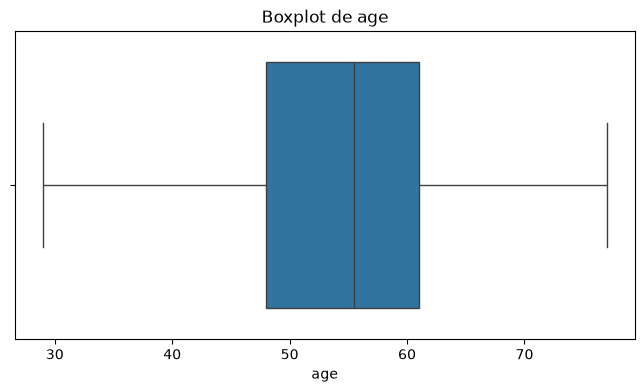

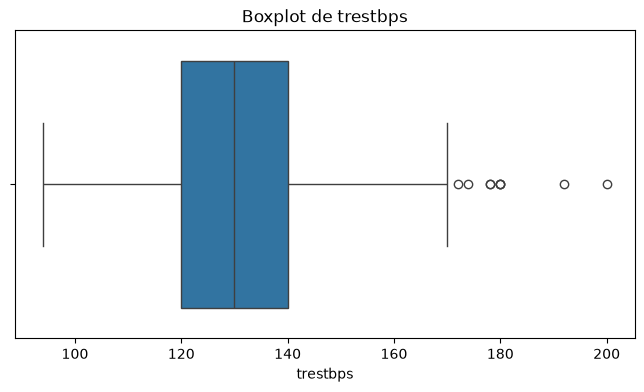

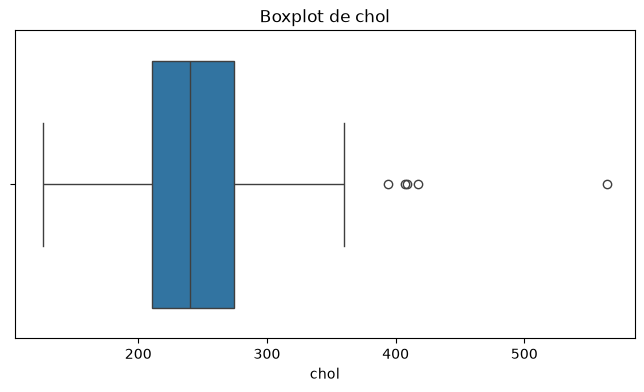

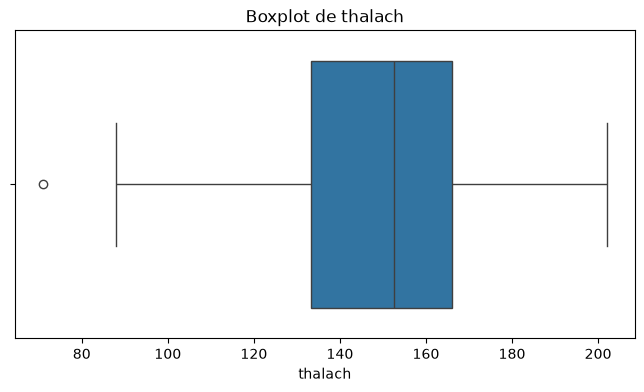

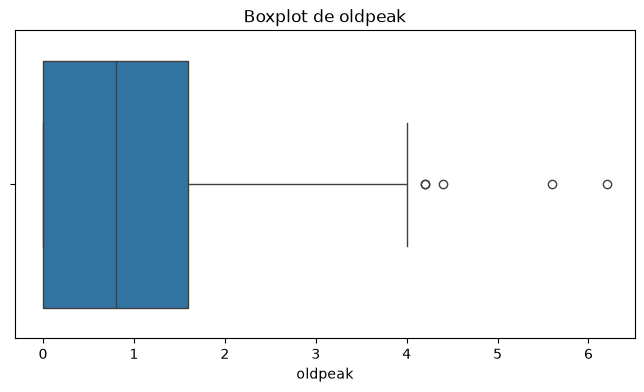

In [15]:
for column in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean[column])
    plt.title(f"Boxplot de {column}")
    plt.show()

## 3.6 Tratamiento de valores atípicos

Los valores atípicos identificados no se eliminan automáticamente, debido
a que las variables representan mediciones clínicas y un valor extremo
puede corresponder a una condición real del paciente.

Por esta razón, los valores atípicos se analizan desde el punto de vista
estadístico y clínico antes de decidir su eliminación.

En ausencia de evidencia de que dichos registros sean errores de medición
o de digitación, se conservan para evitar eliminar información potencialmente
relevante para la clasificación.

## 3.7 Normalización de variables continuas

Las variables continuas presentan diferentes escalas y unidades de medida.
Por esta razón se aplica una normalización mediante StandardScaler.

La estandarización transforma las variables para que tengan media cercana
a 0 y desviación estándar cercana a 1.

Es importante señalar que Random Forest no requiere normalización para
realizar sus divisiones, pero se incluye este proceso debido al requisito
del proyecto y para mantener un flujo de preprocesamiento reproducible.

La transformación se ajustará únicamente utilizando los datos de
entrenamiento para evitar fuga de información (data leakage).

# 4. Análisis exploratorio de datos (EDA)

## 4.1 Distribución de la variable objetivo

La variable `target` representa la presencia o ausencia de enfermedad
cardíaca:

- 0: ausencia.
- 1: presencia.

target
1    164
0    138
Name: count, dtype: int64


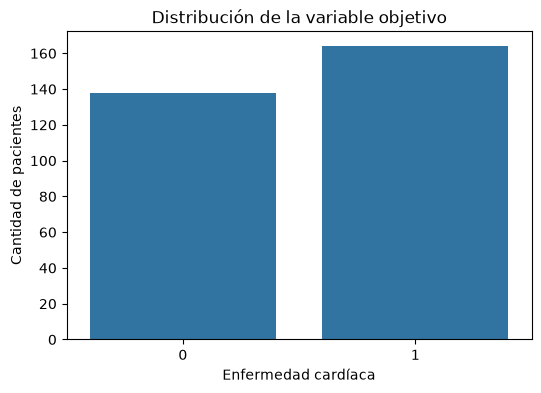

In [16]:
print(df_clean["target"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="target")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Enfermedad cardíaca")
plt.ylabel("Cantidad de pacientes")
plt.show()

## 4.2 Distribución de variables continuas

Se analizan las distribuciones de las variables continuas para identificar
su comportamiento, dispersión y posibles asimetrías.

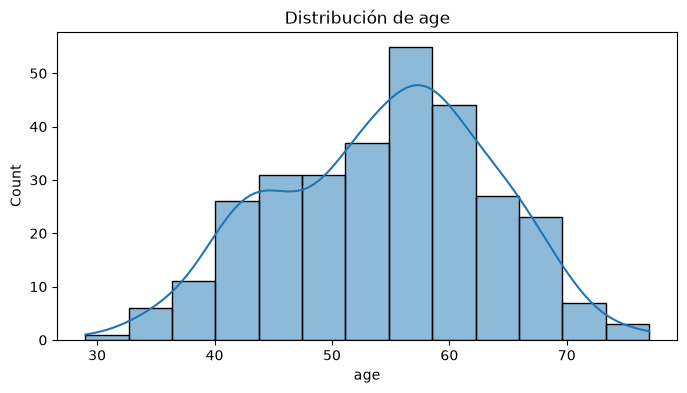

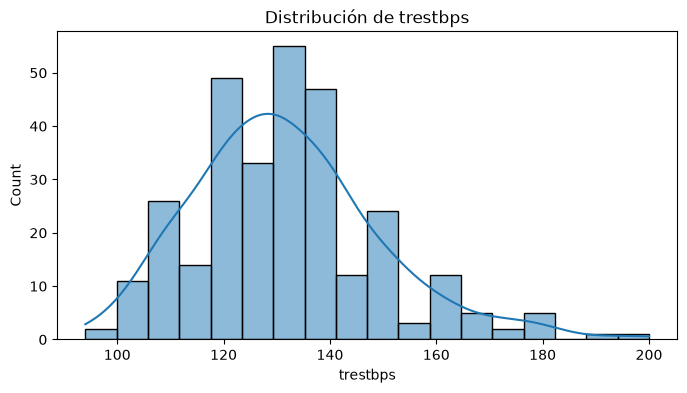

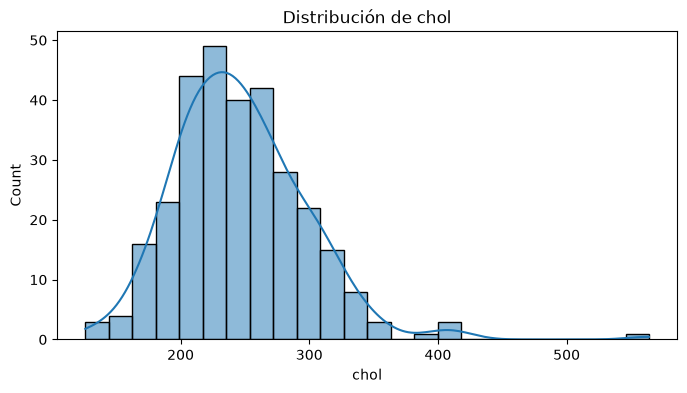

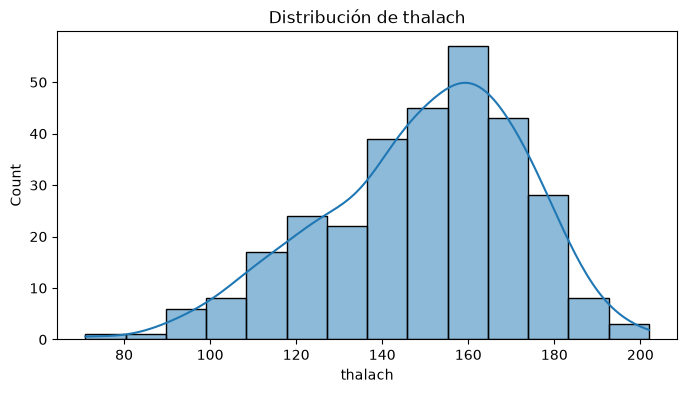

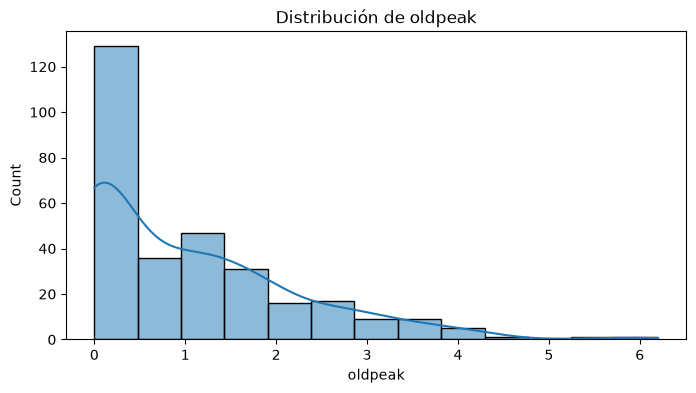

In [17]:
for column in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_clean, x=column, kde=True)
    plt.title(f"Distribución de {column}")
    plt.show()

## 4.3 Relación entre variables continuas y la variable objetivo

Se comparan las variables continuas entre pacientes con y sin enfermedad
cardíaca para identificar posibles diferencias en sus distribuciones.

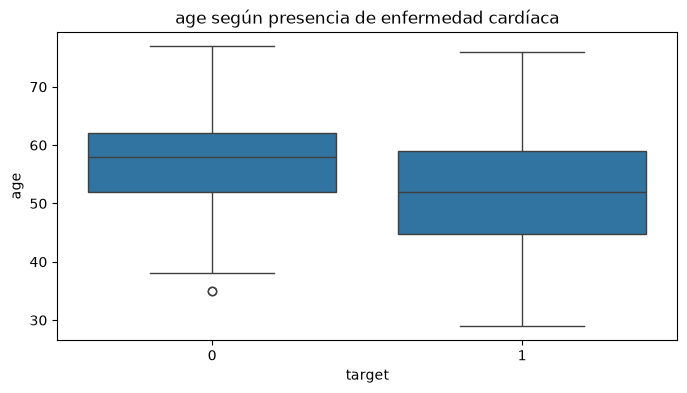

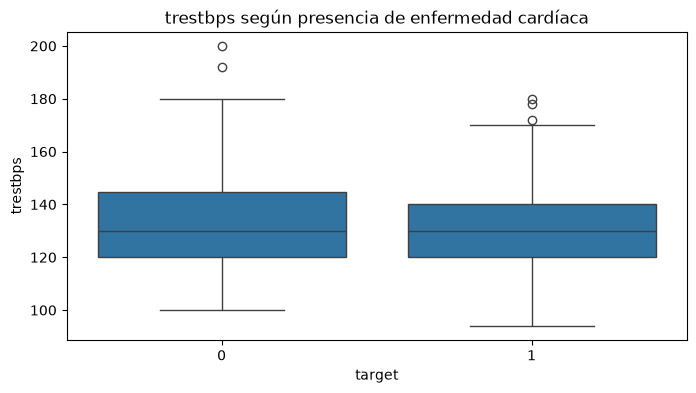

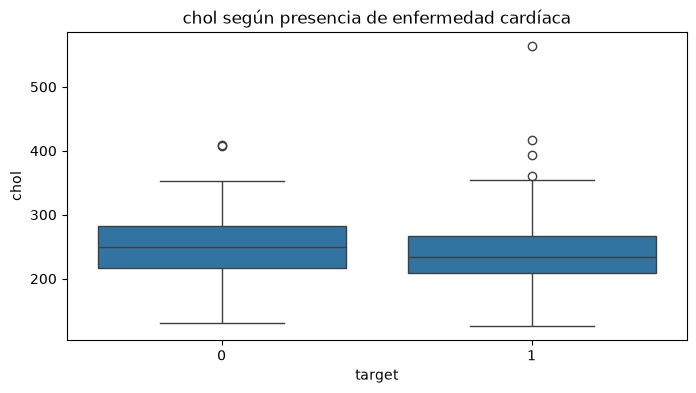

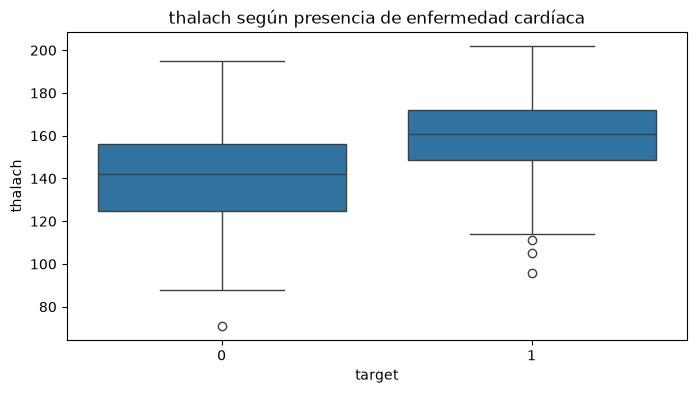

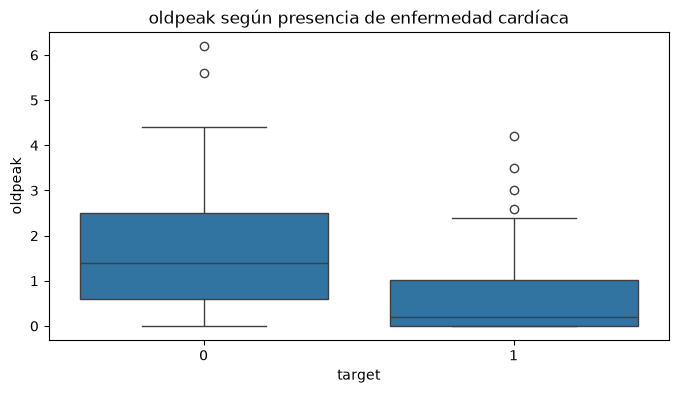

In [18]:
for column in continuous_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_clean, x="target", y=column)
    plt.title(f"{column} según presencia de enfermedad cardíaca")
    plt.show()

## 4.4 Matriz de correlación

Se utiliza una matriz de correlación para analizar la relación lineal entre
las variables numéricas del conjunto de datos.

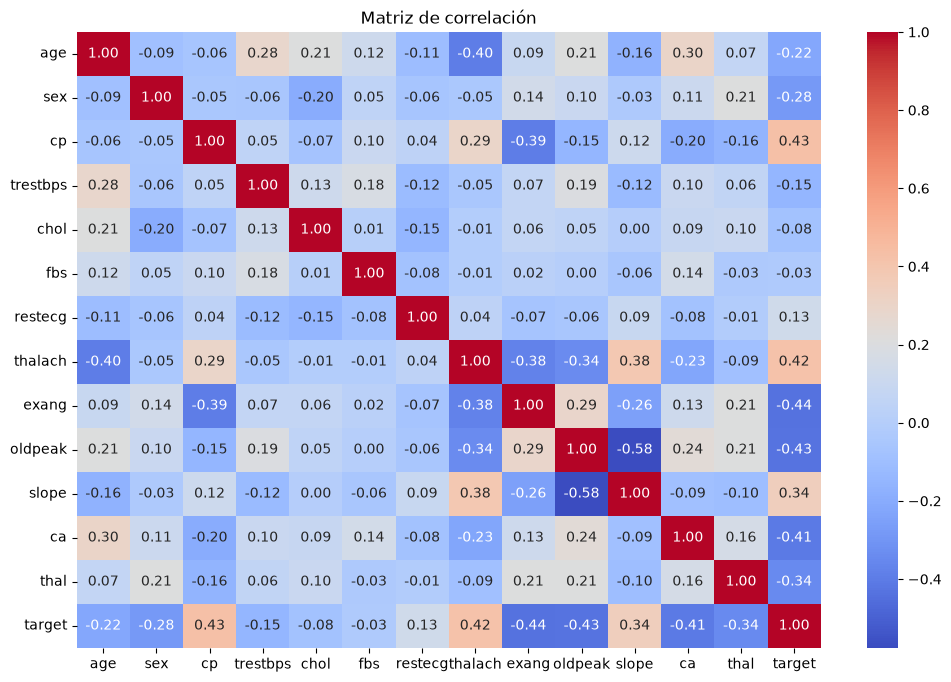

In [19]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

# 5. Definición del problema de Machine Learning

## 5.1 Clasificación vs. Regresión

El problema corresponde a un problema de **clasificación binaria** y no de
regresión.

La variable objetivo `target` tiene dos posibles categorías:

- 0: ausencia de enfermedad cardíaca.
- 1: presencia de enfermedad cardíaca.

El objetivo es determinar a qué categoría pertenece cada paciente.

En un problema de regresión se intentaría predecir un valor numérico
continuo, como por ejemplo el nivel de colesterol o la presión arterial.
En este caso no se busca predecir un valor continuo, sino una categoría.

Por lo tanto, las métricas adecuadas son Accuracy, Precision, Recall,
F1-Score, matriz de confusión y ROC-AUC, en lugar de RMSE, MAE o R².

# 6. Modelado

## 6.1 Definición de variables predictoras y variable objetivo

Las variables predictoras corresponden a las características clínicas
del paciente, mientras que `target` representa la variable objetivo.

In [20]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (302, 13)
Dimensiones de y: (302,)


## 6.2 División de los datos

El conjunto de datos se divide en:

- 80% para entrenamiento.
- 20% para prueba.

Se utiliza `stratify=y` para mantener aproximadamente la misma proporción
de las clases en ambos conjuntos.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (241, 13)
Prueba: (61, 13)


## -Normalización

In [22]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_vars] = scaler.fit_transform(
    X_train[continuous_vars]
)

X_test_scaled[continuous_vars] = scaler.transform(
    X_test[continuous_vars]
)

## 6.3 Selección del algoritmo: Random Forest

Seleccionamos Random Forest como algoritmo principal debido a las
características del conjunto de datos y del problema.

Random Forest es apropiado para datos tabulares y problemas de clasificación
binaria. El algoritmo combina múltiples árboles de decisión para obtener
una predicción más robusta.

Entre sus ventajas se encuentran:

- Capacidad para modelar relaciones no lineales.
- Buen desempeño en conjuntos de datos tabulares.
- Menor riesgo de sobreajuste que un único árbol de decisión.
- No requiere que las variables sigan una distribución específica.
- Permite obtener medidas de importancia de las variables.
- Permite optimizar sus hiperparámetros mediante técnicas como
  GridSearchCV.

Aunque SVM también es una alternativa válida, Random Forest es mas
conveniente para este proyecto debido a su interpretabilidad relativa,
su comportamiento con datos tabulares y la posibilidad de analizar
la importancia de las características.

## -Modelo Base

In [23]:
rf_base = RandomForestClassifier(
    random_state=42
)

rf_base.fit(X_train_scaled, y_train)

y_pred_base = rf_base.predict(X_test_scaled)

## 6.4 Evaluación del modelo base

Antes de optimizar el algoritmo se obtiene un modelo base que sirve como
punto de comparación frente al modelo optimizado.

In [24]:
accuracy_base = accuracy_score(y_test, y_pred_base)
precision_base = precision_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print("Accuracy:", accuracy_base)
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1-Score:", f1_base)

Accuracy: 0.7540983606557377
Precision: 0.7647058823529411
Recall: 0.7878787878787878
F1-Score: 0.7761194029850746


# 7. Optimización del modelo

## 7.1 Optimización de hiperparámetros

Para mejorar el rendimiento del Random Forest se utiliza GridSearchCV.

Esta técnica evalúa diferentes combinaciones de hiperparámetros mediante
validación cruzada estratificada.

Se utiliza F1-Score como métrica principal de optimización debido a que
permite equilibrar Precision y Recall, aspecto importante en un problema
de clasificación médica.

In [25]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

## -Validación cruzada

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 S

## 7.2 Mejores hiperparámetros encontrados

In [27]:
print("Mejores parámetros:")
print(grid_search.best_params_)

print("\nMejor F1-Score promedio:")
print(grid_search.best_score_)

Mejores parámetros:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Mejor F1-Score promedio:
0.875200743062812


## - Modelo Final


In [28]:
rf_final = grid_search.best_estimator_

rf_final.fit(X_train_scaled, y_train)

y_pred = rf_final.predict(X_test_scaled)
y_prob = rf_final.predict_proba(X_test_scaled)[:, 1]

# 8. Evaluación del modelo final

## 8.1 Accuracy

Accuracy representa la proporción de predicciones correctas realizadas
por el modelo sobre el total de observaciones.

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7704918032786885


## 8.2 Precision

Precision indica qué proporción de los pacientes clasificados como positivos
por el modelo realmente pertenecen a la clase positiva.

In [30]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.7878787878787878


## 8.3 Recall

Recall indica la proporción de pacientes que realmente presentan enfermedad
cardíaca y que fueron correctamente identificados por el modelo.

Esta métrica es especialmente relevante en este proyecto debido a que un
falso negativo podría representar un paciente con indicios de enfermedad
que no recibe una alerta.

In [31]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.7878787878787878


## 8.4 F1-Score

F1-Score combina Precision y Recall en una sola métrica y resulta útil
cuando se desea mantener un equilibrio entre ambas.

In [32]:
f1 = f1_score(y_test, y_pred)

print("F1-Score:", f1)

F1-Score: 0.7878787878787878


In [33]:
print("===== RESULTADOS DEL MODELO FINAL =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

===== RESULTADOS DEL MODELO FINAL =====
Accuracy:  0.7705
Precision: 0.7879
Recall:    0.7879
F1-Score:  0.7879



## 8.5 Matriz de confusión

La matriz de confusión permite identificar:

- Verdaderos positivos (TP).
- Verdaderos negativos (TN).
- Falsos positivos (FP).
- Falsos negativos (FN).

En este proyecto se presta especial atención a los falsos negativos,
debido a que representan pacientes con enfermedad cardíaca que podrían
no ser identificados por el modelo.

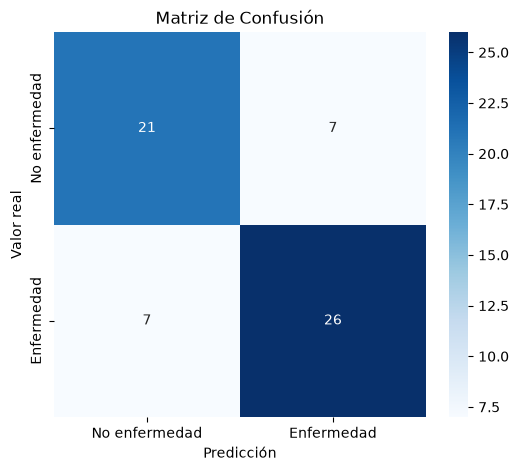

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No enfermedad", "Enfermedad"],
    yticklabels=["No enfermedad", "Enfermedad"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



## 8.6 ROC-AUC

ROC-AUC permite evaluar la capacidad del modelo para distinguir entre
las dos clases considerando diferentes umbrales de clasificación.

In [36]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8582251082251082


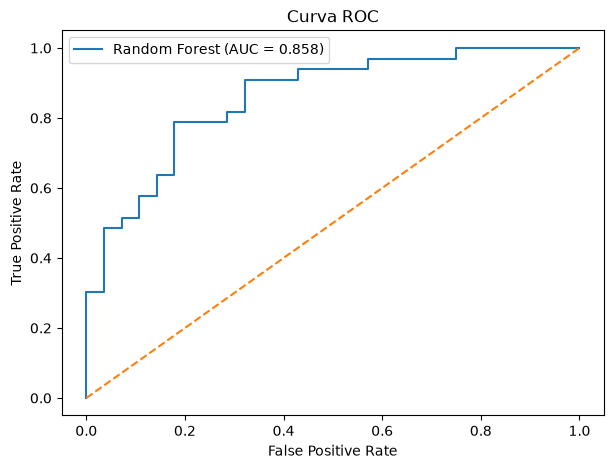

In [37]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

## 8.7 Validación cruzada

La validación cruzada permite comprobar que el rendimiento del modelo no
depende exclusivamente de una única división entre entrenamiento y prueba.

In [38]:
cv_results = grid_search.cv_results_

best_index = grid_search.best_index_

mean_f1 = cv_results["mean_test_score"][best_index]
std_f1 = cv_results["std_test_score"][best_index]

print(f"F1-Score promedio en validación cruzada: {mean_f1:.4f}")
print(f"Desviación estándar: {std_f1:.4f}")

F1-Score promedio en validación cruzada: 0.8752
Desviación estándar: 0.0527


# 9. Comparación del modelo base y el modelo optimizado

Se compara el rendimiento del Random Forest inicial frente al modelo
optimizado mediante GridSearchCV.

In [39]:
comparison = pd.DataFrame({
    "Modelo": ["Random Forest Base", "Random Forest Optimizado"],
    "Accuracy": [
        accuracy_base,
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_base,
        precision_score(y_test, y_pred)
    ],
    "Recall": [
        recall_base,
        recall_score(y_test, y_pred)
    ],
    "F1-Score": [
        f1_base,
        f1_score(y_test, y_pred)
    ]
})

comparison

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest Base,0.754098,0.764706,0.787879,0.776119
1,Random Forest Optimizado,0.770492,0.787879,0.787879,0.787879


# 10. Interpretación del modelo

## 10.1 Importancia de las variables

Random Forest permite estimar la importancia relativa de las variables
utilizadas para realizar las predicciones.

Esta información permite identificar qué características tuvieron mayor
influencia en las decisiones del modelo.

In [40]:
feature_importance = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf_final.feature_importances_
}).sort_values(
    by="Importancia",
    ascending=False
)

feature_importance

,Variable,Importancia
2,cp,0.199828
7,thalach,0.134443
11,ca,0.111488
12,thal,0.107653
8,exang,0.090143
9,oldpeak,0.088556
0,age,0.064520
4,chol,0.056903
3,trestbps,0.048708
1,sex,0.044809


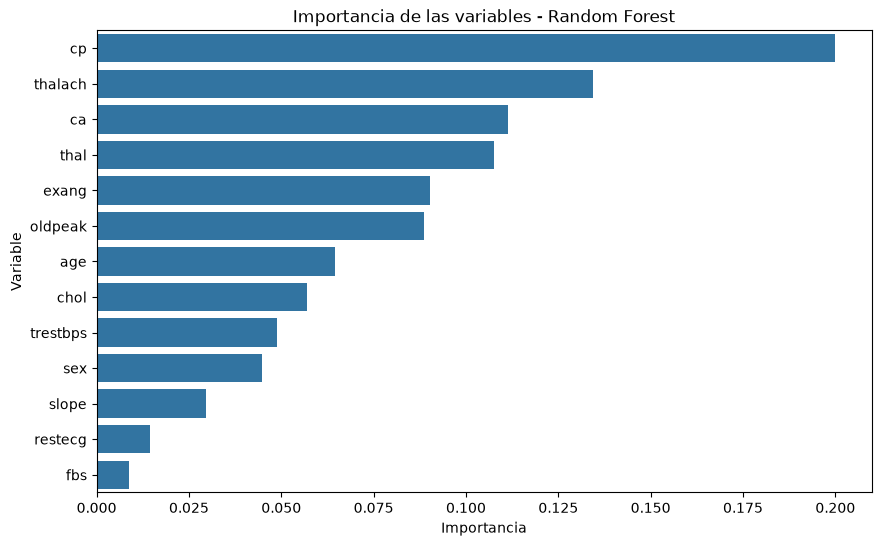

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de las variables - Random Forest")
plt.show()

# 11. Análisis de resultados

El modelo Random Forest optimizado obtuvo los siguientes resultados:

- Accuracy: [RESULTADO]
- Precision: [RESULTADO]
- Recall: [RESULTADO]
- F1-Score: [RESULTADO]
- ROC-AUC: [RESULTADO]

El Recall es especialmente importante en este contexto debido a que
permite evaluar qué proporción de los pacientes con enfermedad cardíaca
fueron correctamente identificados.

La matriz de confusión permitió identificar la cantidad de verdaderos
positivos, verdaderos negativos, falsos positivos y falsos negativos.

Los hiperparámetros seleccionados mediante GridSearchCV fueron:

[INSERTAR MEJORES PARÁMETROS]

Las variables con mayor importancia según Random Forest fueron:

[INSERTAR RESULTADOS DE IMPORTANCIA]

# 12. Despliegue propuesto

## 12.1 Integración con el sistema de historia clínica electrónica

Se propone integrar el modelo como un servicio de apoyo a la decisión
clínica dentro del sistema de historia clínica electrónica.

El flujo propuesto sería:

1. El profesional registra o consulta los datos clínicos del paciente.
2. El sistema obtiene las variables requeridas por el modelo.
3. Los datos pasan por el mismo proceso de preparación utilizado durante
   el entrenamiento.
4. El modelo Random Forest genera una predicción.
5. El sistema presenta el resultado como una alerta o indicador de riesgo.
6. El profesional de la salud utiliza esta información como apoyo para
   decidir si se requieren evaluaciones adicionales.

El modelo no debe considerarse un sustituto del diagnóstico médico,
sino una herramienta de apoyo a la decisión clínica.

# 13. Conclusiones

1. El problema fue identificado como un problema de clasificación binaria,
   debido a que la variable objetivo representa la presencia o ausencia
   de enfermedad cardíaca.

2. Durante la preparación de los datos se identificaron y trataron
   registros duplicados, valores faltantes, posibles valores inválidos
   y valores atípicos.

3. Se realizó un análisis exploratorio para comprender la distribución
   de las variables y su relación con la variable objetivo.

4. Se aplicó normalización a las variables continuas utilizando
   StandardScaler, ajustando la transformación únicamente sobre los
   datos de entrenamiento.

5. Se seleccionó Random Forest debido a su capacidad para trabajar con
   datos tabulares y relaciones no lineales, además de permitir la
   optimización de hiperparámetros y el análisis de importancia de
   variables.

6. El modelo fue optimizado mediante GridSearchCV y validación cruzada
   estratificada.

7. El rendimiento final fue evaluado mediante Accuracy, Precision, Recall,
   F1-Score, matriz de confusión y ROC-AUC.

8. Los resultados obtenidos indican que el modelo puede ser considerado
   como una herramienta de apoyo para identificar pacientes que podrían
   requerir una evaluación adicional.

9. Debido a la naturaleza del problema y a las características del
   conjunto de datos, el modelo no debe utilizarse como sustituto de
   una evaluación o diagnóstico realizado por un profesional de la salud.

# 14. Referencias

- UCI Machine Learning Repository. Heart Disease Dataset.
- Kaggle. Heart Disease Dataset.
- Scikit-learn Documentation. Random Forest Classifier.
- Scikit-learn Documentation. GridSearchCV.
- Scikit-learn Documentation. Classification Metrics.